In [1]:
'''
Recognising fraudulent credit card transactions so that customers are not charged for items that they did not purchase.
'''
#!pip install --upgrade numpy scipy scikit-learn mlxtend


'\nRecognising fraudulent credit card transactions so that customers are not charged for items that they did not purchase.\n'

In [2]:
# Importing Relevant Libraries

import numpy as np 
import pandas as pd 
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder 
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score 
from sklearn.metrics import accuracy_score

In [3]:
# Exploratory Data Analysis
df = pd.read_csv(r'creditcard.csv')

print(f'\n {df.head(5)}')

#print(df.describe())

#print(df.shape)

print(df.isnull().sum())


    Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V2

In [4]:
#Further EDA - Fraudulent Transactions

'''
 Feature 'Class' is the response variable and it takes value 1 in case of fraud and 0 otherwise.
 Feature 'Time' contains the seconds elapsed between each transaction and the first transaction in the dataset.
 The feature 'Amount' is the transaction Amount, this feature can be used for example-dependant cost-sensitive learning.
'''

fraud_count = df['Class'].sum()
legitimate = len(df) - fraud_count
fraud_percentage = (fraud_count/len(df)) * 100

print(f"\nFraud transactions: {fraud_count:,} ({fraud_percentage:.4f}%)")
print(f"Legitimate transactions: {legitimate:,} ({100-fraud_percentage:.4f}%)")
print(f"Imbalance ratio: 1:{int(legitimate/fraud_count)}")


Fraud transactions: 492 (0.1727%)
Legitimate transactions: 284,315 (99.8273%)
Imbalance ratio: 1:577


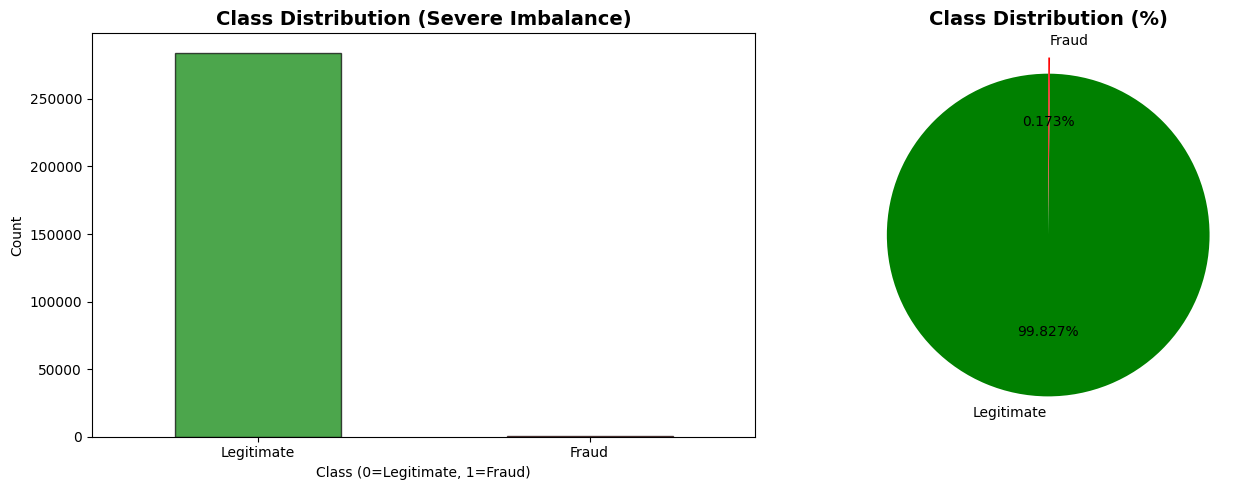

In [5]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
df['Class'].value_counts().plot(kind='bar', ax=axes[0], color=['green', 'red'], alpha=0.7, edgecolor='black')
axes[0].set_title('Class Distribution (Severe Imbalance)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Class (0=Legitimate, 1=Fraud)')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['Legitimate', 'Fraud'], rotation=0)

# Pie chart
df['Class'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.3f%%', 
                                 colors=['green', 'red'], labels=['Legitimate', 'Fraud'],
                                 startangle=90, explode=(0, 0.1))
axes[1].set_title('Class Distribution (%)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
#plt.savefig('01_class_imbalance.png', dpi=300, bbox_inches='tight')
plt.show()

In [6]:
'''
The model has a 99.83% classification acccuracy however this is largely due to the class imbalance of the dataset where 0.1727% of the dataset are fraudulent transactions.
To Scrutinise this further we will look into adressing the class imbalance using techniques like but not limited to:
    1. Using various evaluation metrics like classification report/matrix, f1_score, roc and auc etc.
    2. Resampling the data set (Upsampling and Downsampling)
    3. Hyperparamter Tuning on the Logistic Regression model
    4. Feature Subset Selection
'''

'\nThe model has a 99.83% classification acccuracy however this is largely due to the class imbalance of the dataset where 0.1727% of the dataset are fraudulent transactions.\nTo Scrutinise this further we will look into adressing the class imbalance using techniques like but not limited to:\n    1. Using various evaluation metrics like classification report/matrix, f1_score, roc and auc etc.\n    2. Resampling the data set (Upsampling and Downsampling)\n    3. Hyperparamter Tuning on the Logistic Regression model\n    4. Feature Subset Selection\n'

In [7]:
# Correlation with Class
correlations = df.corr()['Class'].sort_values(ascending=False)
print("Top 10 features correlated with Fraud:")
print(correlations.head(14))  # 11 because Class correlates with itself

Top 10 features correlated with Fraud:
Class     1.000000
V11       0.154876
V4        0.133447
V2        0.091289
V21       0.040413
V19       0.034783
V20       0.020090
V8        0.019875
V27       0.017580
V28       0.009536
Amount    0.005632
V26       0.004455
V25       0.003308
V22       0.000805
Name: Class, dtype: float64


In [8]:
'''
Exploratory Data Analysis Completed

The large numerical range of Amount and the extreme class imbalance is is the main issue going into the PreProcessing Stage.
'''

'\nExploratory Data Analysis Completed\n\nThe large numerical range of Amount and the extreme class imbalance is is the main issue going into the PreProcessing Stage.\n'

In [9]:
# Data PreProcessing - scale amounts and time columns to match the scaled columns V1-V28

std_scaler = StandardScaler()

df['scaled_amount'] = std_scaler.fit_transform(df['Amount'].values.reshape(-1, 1))
df['scaled_time'] = std_scaler.fit_transform(df['Amount'].values.reshape(-1, 1))

df.drop(['Time', 'Amount'], axis = 1, inplace = True)

In [10]:
# Splitting Data into X and y
X = df.drop('Class', axis = 1)
y = df['Class'] #Target Variable

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeatures: {list(X.columns)}")

Features shape: (284807, 30)
Target shape: (284807,)

Features: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'scaled_amount', 'scaled_time']


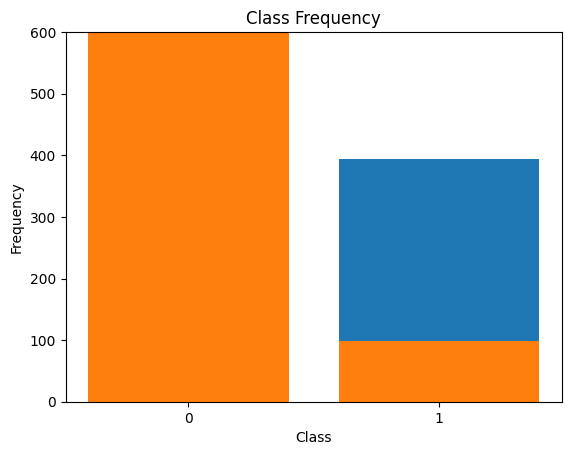


Class distribution in training set:
Class
0    227451
1       394
Name: count, dtype: int64
Fraud %: 0.1729%

Class distribution in test set:
Class
0    56864
1       98
Name: count, dtype: int64
Fraud %: 0.1720%


In [11]:
# Train Test Split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify = y, random_state = 42)

unique, counts = np.unique(y_train, return_counts = True)
plt.bar(unique, counts)
unique, counts = np.unique(y_test, return_counts = True)
plt.bar(unique, counts)

plt.title('Class Frequency')
plt.xlabel('Class')
plt.ylabel('Frequency')
plt.xticks(ticks = [0,1], labels = [0,1])
plt.ylim(top = 600)

plt.show()
y.value_counts()

print("\nClass distribution in training set:")
print(y_train.value_counts())
print(f"Fraud %: {y_train.mean()*100:.4f}%")

print("\nClass distribution in test set:")
print(y_test.value_counts())
print(f"Fraud %: {y_test.mean()*100:.4f}%")

In [12]:
# Baseline Logistic Regression Model on Imbalanced Dataset
from sklearn.metrics import average_precision_score
from sklearn.metrics import classification_report
#Model Instance and Fitting
lr_baseline = LogisticRegression(max_iter = 1000, random_state = 42)
lr_baseline.fit(X_train, y_train)

# Predict 

y_pred_baseline = lr_baseline.predict(X_test)
y_pred_proba_baseline = lr_baseline.predict_proba(X_test)[:, 1]

# 3. Evaluate

print("--- Baseline Logistic Regression Performance ---")
print(classification_report(y_test, y_pred_baseline, target_names = ['Legitimate', 'Fraud'], digits = 4))
print('\n F1 Score')
print(f1_score(y_test, y_pred_baseline))
print('\n Confusion Matrix')
print(confusion_matrix(y_test, y_pred_baseline))
print('\n ROC_AUC_Score')
print(roc_auc_score(y_test, y_pred_proba_baseline))
print('\n Precision Score')
print(precision_score(y_test, y_pred_baseline))
print('\n Recall Score')
print(recall_score(y_test, y_pred_baseline))
print('\n Accuracy Score')
print(accuracy_score(y_test, y_pred_baseline))
print('\n Probaility of Fraud')
print(y_pred_proba_baseline)
print('\n')
auprc = average_precision_score(y_test, y_pred_proba_baseline)
print(f'Area Under Precision-Recall Curve (AUPRC): {auprc:.4f}')

--- Baseline Logistic Regression Performance ---
              precision    recall  f1-score   support

  Legitimate     0.9994    0.9998    0.9996     56864
       Fraud     0.8267    0.6327    0.7168        98

    accuracy                         0.9991     56962
   macro avg     0.9130    0.8162    0.8582     56962
weighted avg     0.9991    0.9991    0.9991     56962


 F1 Score
0.7167630057803468

 Confusion Matrix
[[56851    13]
 [   36    62]]

 ROC_AUC_Score
0.9574222204357263

 Precision Score
0.8266666666666667

 Recall Score
0.6326530612244898

 Accuracy Score
0.9991397773954567

 Probaility of Fraud
[8.72850716e-05 3.06318253e-05 1.35916386e-05 ... 1.87417185e-05
 3.89458775e-05 1.98811085e-04]


Area Under Precision-Recall Curve (AUPRC): 0.7420


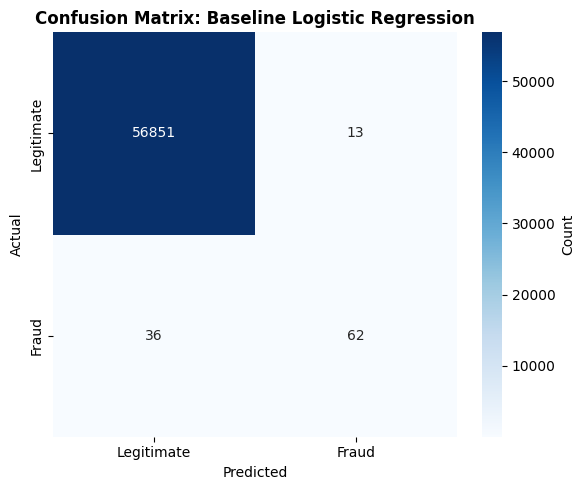

[[55377  1487]
 [    8    90]]

True Negatives (Correct Legitimate):  56,851
False Positives (Blocked Legitimate): 13
False Negatives (Missed Fraud):       36
True Positives (Caught Fraud):        62


In [20]:
# Visualise Baseline Model Evaluation Results (Heatmap Only)
cm_baseline = confusion_matrix(y_test, y_pred_baseline)

plt.figure(figsize=(6, 5))

# Heatmap
sns.heatmap(cm_baseline, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate', 'Fraud'],
            yticklabels=['Legitimate', 'Fraud'],
            cbar_kws={'label': 'Count'})

plt.title('Confusion Matrix: Baseline Logistic Regression', fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')

plt.tight_layout()
plt.savefig('04_baseline_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

cm_basline = confusion_matrix(y_test, y_pred_baseline)
print(cm_smote)

tn, fp, fn, tp = cm_baseline.ravel()
print(f"\nTrue Negatives (Correct Legitimate):  {tn:,}")
print(f"False Positives (Blocked Legitimate): {fp:,}")
print(f"False Negatives (Missed Fraud):       {fn}")
print(f"True Positives (Caught Fraud):        {tp}")

In [14]:
# The % magic ensures the installation happens in your current Jupyter kernel
#%pip install -U scikit-learn imbalanced-learn


In [16]:
# Addressing Dataset Imbalance using SMOTE - so that our model is not biased towards the majority class (0)

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state = 42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\nClass distribution in training set:")
print(y_train_smote.value_counts())
print(f"Fraud %: {y_train_smote.mean()*100:.4f}%")



Class distribution in training set:
Class
0    227451
1    227451
Name: count, dtype: int64
Fraud %: 50.0000%


In [18]:
# Training the Logistic Regression Model 
lr_smote = LogisticRegression(random_state = 42, max_iter = 1000)
lr_smote.fit(X_train_smote, y_train_smote)

# Predictions

y_pred_smote = lr_smote.predict(X_test)
y_pred_proba_smote = lr_smote.predict_proba(X_test)[:, 1]

# 3. Evaluate

print("--- Baseline Logistic Regression Performance ---")
print(classification_report(y_test, y_pred_smote, target_names = ['Legitimate', 'Fraud'], digits = 4))
print('\n F1 Score')
print(f1_score(y_test, y_pred_smote))
print('\n Confusion Matrix')
print(confusion_matrix(y_test, y_pred_smote))
print('\n ROC_AUC_Score')
print(roc_auc_score(y_test, y_pred_proba_smote))
print('\n Precision Score')
print(precision_score(y_test, y_pred_smote))
print('\n Recall Score')
print(recall_score(y_test, y_pred_smote))
print('\n Accuracy Score')
print(accuracy_score(y_test, y_pred_smote))
print('\n Probaility of Fraud')
print(y_pred_proba_smote)
print('\n')
auprc = average_precision_score(y_test, y_pred_proba_smote)
print(f'Area Under Precision-Recall Curve (AUPRC): {auprc:.4f}')

--- Baseline Logistic Regression Performance ---
              precision    recall  f1-score   support

  Legitimate     0.9999    0.9738    0.9867     56864
       Fraud     0.0571    0.9184    0.1075        98

    accuracy                         0.9738     56962
   macro avg     0.5285    0.9461    0.5471     56962
weighted avg     0.9982    0.9738    0.9852     56962


 F1 Score
0.10746268656716418

 Confusion Matrix
[[55377  1487]
 [    8    90]]

 ROC_AUC_Score
0.9697458418510906

 Precision Score
0.05707038681039949

 Recall Score
0.9183673469387755

 Accuracy Score
0.9737544327797479

 Probaility of Fraud
[3.23483910e-03 4.47906154e-02 3.33723813e-05 ... 4.52425586e-04
 1.36083498e-03 5.26095615e-02]


Area Under Precision-Recall Curve (AUPRC): 0.7236


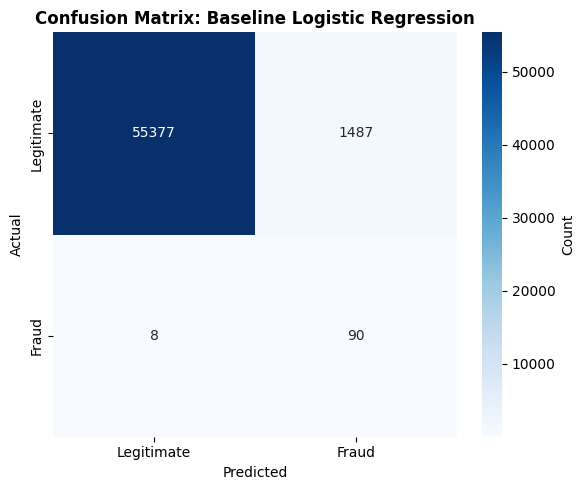

[[55377  1487]
 [    8    90]]

True Negatives (Correct Legitimate):  55,377
False Positives (Blocked Legitimate): 1,487
False Negatives (Missed Fraud):       8
True Positives (Caught Fraud):        90


In [19]:
# Visualise Baseline Model Evaluation Results (Heatmap Only)
cm_smote = confusion_matrix(y_test, y_pred_smote)

plt.figure(figsize=(6, 5))

# Heatmap
sns.heatmap(cm_smote, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate', 'Fraud'],
            yticklabels=['Legitimate', 'Fraud'],
            cbar_kws={'label': 'Count'})

plt.title('Confusion Matrix: Baseline Logistic Regression', fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')

plt.tight_layout()
plt.savefig('04_baseline_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

cm_smote = confusion_matrix(y_test, y_pred_smote)
print(cm_smote)

tn, fp, fn, tp = cm_smote.ravel()
print(f"\nTrue Negatives (Correct Legitimate):  {tn:,}")
print(f"False Positives (Blocked Legitimate): {fp:,}")
print(f"False Negatives (Missed Fraud):       {fn}")
print(f"True Positives (Caught Fraud):        {tp}")

In [23]:
# Trying to improve our base model using class weights 
lr_cw = LogisticRegression(random_state = 42, max_iter = 1000, class_weight = 'balanced')
lr_cw.fit(X_train, y_train)

# Predictions
y_pred_cw = lr_cw.predict(X_test)
y_pred_proba_cw = lr_cw.predict_proba(X_test)[: , 1]

# 3. Evaluate

print("--- Baseline Logistic Regression Performance ---")
print(classification_report(y_test, y_pred_cw, target_names = ['Legitimate', 'Fraud'], digits = 4))
print('\n F1 Score')
print(f1_score(y_test, y_pred_cw))
print('\n Confusion Matrix')
print(confusion_matrix(y_test, y_pred_cw))
print('\n ROC_AUC_Score')
print(roc_auc_score(y_test, y_pred_proba_cw))
print('\n Precision Score')
print(precision_score(y_test, y_pred_cw))
print('\n Recall Score')
print(recall_score(y_test, y_pred_cw))
print('\n Accuracy Score')
print(accuracy_score(y_test, y_pred_cw))
print('\n Probaility of Fraud')
print(y_pred_proba_cw)
print('\n')
auprc = average_precision_score(y_test, y_pred_proba_cw)
print(f'Area Under Precision-Recall Curve (AUPRC): {auprc:.4f}')

--- Baseline Logistic Regression Performance ---
              precision    recall  f1-score   support

  Legitimate     0.9999    0.9747    0.9871     56864
       Fraud     0.0588    0.9184    0.1106        98

    accuracy                         0.9746     56962
   macro avg     0.5293    0.9465    0.5488     56962
weighted avg     0.9982    0.9746    0.9856     56962


 F1 Score
0.11056511056511056

 Confusion Matrix
[[55424  1440]
 [    8    90]]

 ROC_AUC_Score
0.9713778237800467

 Precision Score
0.058823529411764705

 Recall Score
0.9183673469387755

 Accuracy Score
0.9745795442575752

 Probaility of Fraud
[0.005785   0.05810625 0.00010053 ... 0.0003992  0.00494345 0.0836315 ]


Area Under Precision-Recall Curve (AUPRC): 0.7182


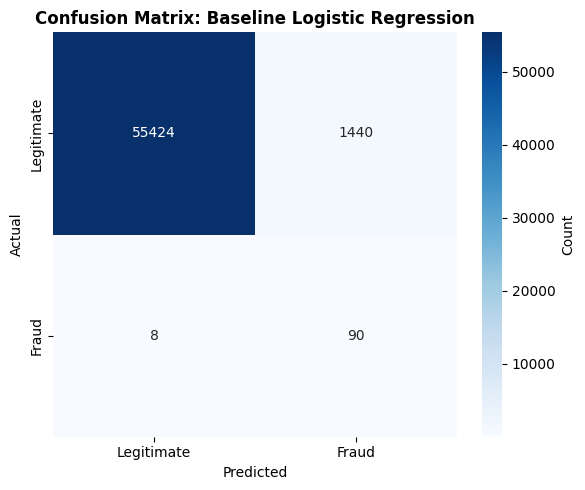

[[55424  1440]
 [    8    90]]

True Negatives (Correct Legitimate):  55,424
False Positives (Blocked Legitimate): 1,440
False Negatives (Missed Fraud):       8
True Positives (Caught Fraud):        90


In [24]:
# Visualise Baseline Model Evaluation Results (Heatmap Only)
cm_cw = confusion_matrix(y_test, y_pred_cw)

plt.figure(figsize=(6, 5))

# Heatmap
sns.heatmap(cm_cw, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate', 'Fraud'],
            yticklabels=['Legitimate', 'Fraud'],
            cbar_kws={'label': 'Count'})

plt.title('Confusion Matrix: Baseline Logistic Regression', fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')

plt.tight_layout()
plt.savefig('04_baseline_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

cm_cw = confusion_matrix(y_test, y_pred_cw)
print(cm_cw)

tn, fp, fn, tp = cm_cw.ravel()
print(f"\nTrue Negatives (Correct Legitimate):  {tn:,}")
print(f"False Positives (Blocked Legitimate): {fp:,}")
print(f"False Negatives (Missed Fraud):       {fn}")
print(f"True Positives (Caught Fraud):        {tp}")

In [26]:
# Model Comparisons

# ACCURACY: Baseline LR - SMOTE - LR+ClassWeights
accuracy_baseline = accuracy_score(y_test, y_pred_baseline)
accuracy_smote = accuracy_score(y_test, y_pred_smote)
accuracy_cw = accuracy_score(y_test, y_pred_cw)

# PRECISION: Baseline LR - SMOTE - LR+ClassWeights
precision_baseline = precision_score(y_test, y_pred_baseline)
precision_smote = precision_score(y_test, y_pred_smote)
precision_cw = precision_score(y_test, y_pred_cw)

# RECALL: Baseline LR - SMOTE - LR+ClassWeights
recall_baseline = recall_score(y_test, y_pred_baseline)
recall_smote = recall_score(y_test, y_pred_smote)
recall_cw = recall_score(y_test, y_pred_cw)

# F1 SCORE: Baseline LR - SMOTE - LR+ClassWeights
f1_baseline = f1_score(y_test, y_pred_baseline)
f1_smote = f1_score(y_test, y_pred_smote)
f1_cw = f1_score(y_test, y_pred_cw)

# ROC_AUC: Baseline LR - SMOTE - LR+ClassWeights
roc_auc_baseline = roc_auc_score(y_test, y_pred_proba_baseline)
roc_auc_smote = roc_auc_score(y_test, y_pred_proba_smote)
roc_auc_cw = roc_auc_score(y_test, y_pred_proba_cw)

comparison = pd.DataFrame({
    'Model': ['Baseline LR', 'LR + SMOTE', 'LR + Class Weights'],
    'Accuracy': [accuracy_baseline, accuracy_smote, accuracy_cw],
    'Precision': [precision_baseline, precision_smote, precision_cw],
    'Recall': [recall_baseline, recall_smote, recall_cw],
    'F1 Score': [f1_baseline, f1_smote, f1_cw],
    'ROC-AUC': [roc_auc_baseline, roc_auc_smote, roc_auc_cw]
})

print("\n" + "=" * 60)
print("MODEL COMPARISON")
print("=" * 60)
print(comparison.to_string(index=False))


MODEL COMPARISON
             Model  Accuracy  Precision   Recall  F1 Score  ROC-AUC
       Baseline LR  0.999140   0.826667 0.632653  0.716763 0.957422
        LR + SMOTE  0.973754   0.057070 0.918367  0.107463 0.969746
LR + Class Weights  0.974580   0.058824 0.918367  0.110565 0.971378
